## Downstream analysis for MAGSs-HMM Annotation & MAGS-gtdbtk 
#### module: mags_hmm_annotation & mags_tax_annotation
HMM scores count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup.yaml -p mags_hmmsearch --mags_hmmsearch_outfolder hmm_proka_paper

```
Taxa abundances from mags_gtdbtk module are aggregated as well:

```bash 
geomosaic gather -s gmsetup.yaml -p mags_gtdbtk
```


In [159]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(tidyverse)
library(stringr)
library(ggplot2)
library(vegan)
library(pheatmap)
library(ComplexHeatmap)
library(circlize)

options(readr.show_col_types = FALSE)

In [160]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

### ALL samples ###

In [161]:
# 1. List all HMM coverage files from your 8 samples
# Geomosaic organizes these in {wdir}/{sample}/{mags_hmmsearch_output_folder}
files <- list.files(path = "../tables/gm_gathering/mags_hmmsearch", pattern = "mags.tsv", recursive = TRUE, full.names = TRUE)


In [162]:
all_data <- map_df(files, function(f) {

  s_name <- basename(dirname(f))
  
  df <- read_delim(f, delim = "\t")
  
  # 3. Pivot from wide to long
  # We keep 'HMM_model' and turn all 'mag_X' columns into a single 'MAG_ID' column
  df_long <- df %>%
    pivot_longer(
      cols = -HMM_model, 
      names_to = "local_mag", 
      values_to = "presence_val"
    ) %>%
    # 4. Create the Global Unique ID and clean the binary value
    mutate(
      Global_MAG_ID = paste0(s_name, "_", local_mag),
      binary_value = ifelse(presence_val == "0", 0, 1)
    ) %>%
    select(HMM_model, Global_MAG_ID, binary_value)
  
  return(df_long)
})

master_matrix <- all_data %>%
  pivot_wider(
    names_from = Global_MAG_ID, 
    values_from = binary_value, 
    values_fill = 0
  )

In [163]:
master_df <- as.data.frame(master_matrix)
rownames(master_df) <- master_df$HMM_model
master_df$HMM_model <- NULL

In [164]:
ko_metadata <- read_delim("../tables/geomosaic_biogeochemical_kos_plot.tsv", delim = "\t")

In [165]:
plot_data <- master_matrix %>%
  inner_join(ko_metadata, by = c("HMM_model" = "KO")) %>%
  arrange(cycle) # Group them by biological function

In [166]:
dim(plot_data)

[1] 133 198

In [167]:
unique_cats <- unique(plot_data$cycle)

# Generate a palette automatically (using 1 color per category)
library(RColorBrewer)
my_palette <- brewer.pal(n = max(3, length(unique_cats)), name = "Set1")

# Create the named vector: c("Nitrogen" = "#E41A1C", "Carbon" = "#377EB8", ...)
cat_colors <- setNames(my_palette[1:length(unique_cats)], unique_cats)

In [168]:
mat <- plot_data %>% 
  select(starts_with("CR18_")) %>% # Selects columns like S1_mag_1, S2_mag_1...
  as.matrix()

In [169]:
# 1. Ensure cat_colors is ready (as we did before)
unique_cats <- unique(plot_data$cycle)
cat_colors <- setNames(RColorBrunique_cats <- unique(plot_data$cycle)

# Generate a palette automatically (using 1 color per category)
my_palette <- brewer.pal(n = max(3, length(unique_cats)), name = "Set1")

# Create the named vector: c("Nitrogen" = "#E41A1C", "Carbon" = "#377EB8", ...)
cat_colors <- setNames(my_palette[1:length(unique_cats)], unique_cats)ewer::brewer.pal(length(unique_cats), "Set1"), unique_cats)

mag_labels = anno_text(colnames(mat), 
                       rot = 90, 
                       just = "right", 
                       offset = unit(1, "npc") - unit(2, "mm"),
                       gp = gpar(fontsize = 7))

# 2. Build the Heatmap with layer_fun
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), # Base grid
        
        # VECTORIZED COLORING (Faster for >100 rows/cols)
        layer_fun = function(j, i, x, y, width, height, fill) {
            # Find the index of all '1' values in the matrix
            v = pindex(mat, i, j)
            
            # Only draw where value is 1
            l = v == 1
            
            # Map the category color to the specific row index 'i'
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[plot_data$cycle[i[l]]], col = NA))
        },
        
        # Row and Column structure
        row_split = plot_data$cycle,
        cluster_rows = FALSE, 
        cluster_columns = TRUE, 
        show_column_names = FALSE,
        row_title_rot = 0,
        bottom_annotation = HeatmapAnnotation(MAG_IDs = mag_labels),
        column_title = "Metabolic Profile by MAG",
        column_title_side = "top",
        # Annotations
        left_annotation = rowAnnotation(Cycle = plot_data$cycle, col = list(Cycle = cat_colors)),
        border = TRUE)

draw(hb)

ERROR: Error in parse(text = input): <text>:6:1: unexpected symbol
5: # Generate a palette automatically (using 1 color per category)
6: my_palette
   ^


In [ ]:
# 1. Create the Row Annotation (The color bar on the left)
row_ha = rowAnnotation(
    Cycle = plot_data$cycle, 
    col = list(Cycle = cat_colors),
    show_legend = TRUE
)

# 2. Build the Heatmap
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), # Base colors
        
        # This logic colors the '1's based on the row's Category
        cell_fun = function(j, i, x, y, width, height, fill) {
            if(mat[i, j] == 1) {
                grid.rect(x, y, width, height, 
                          gp = gpar(fill = cat_colors[plot_data$cycle[i]], col = NA))
            }
        },
        
        left_annotation = row_ha, # Adds the color bar
        row_split = plot_data$cycle,
        cluster_rows = FALSE, 
        show_column_names = FALSE,
        row_title_rot = 0,
        column_title = "MAGs (8 Samples)",
        border = TRUE)

draw(hb, heatmap_legend_side = "right", annotation_legend_side = "right")

ERROR: Error: Length or nrow of `row_split` should be same as nrow of `matrix`.


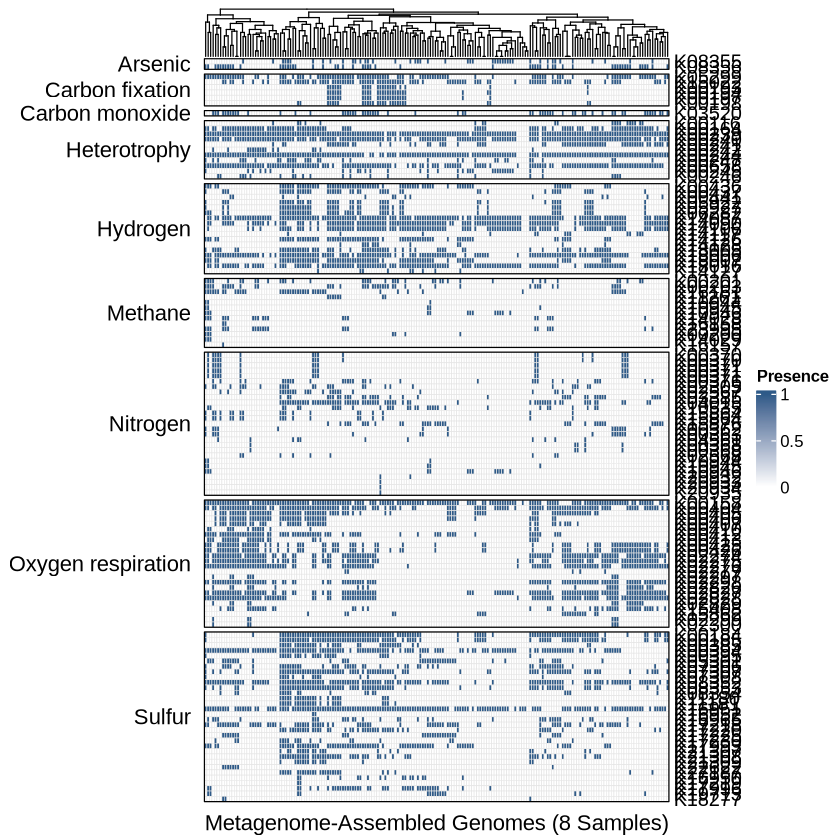

In [ ]:
mat <- plot_data %>% 
  select(starts_with("CR18_")) %>% # Selects columns like S1_mag_1, S2_mag_1...
  as.matrix()

rownames(mat) <- plot_data$HMM_model

# 2. Define colors (Binary: 0 = White, 1 = Your Lab Color)
col_fun = colorRamp2(c(0, 1), c("white", "#2E5A88")) 

# 3. Generate the Heatmap
hb <- Heatmap(mat, 
        name = "Presence",
        col = col_fun,
        
        # Row options (Functional Grouping)
        row_split = plot_data$cycle, # This creates the gaps between N, C, S cycles
        row_title_rot = 0,
        cluster_rows = FALSE, # Keep the order from your template
        
        # Column options (MAGs)
        column_split = str_extract(colnames(mat), "^S[0-9]+"), # Split by Sample ID
        column_title_side = "bottom",
        show_column_names = FALSE, # Too many MAGs to show names clearly
        
        # Aesthetics
        border = TRUE,
        rect_gp = gpar(col = "gray90", lwd = 0.5), # Thin grid lines
        column_title = "Metagenome-Assembled Genomes (8 Samples)")

# Draw it!
draw(hb, merge_legend = TRUE)

### SINGLE SAMPLE HEATMAP ###


In [ ]:
# 1. List all HMM coverage files from your 8 samples
# Geomosaic organizes these in {wdir}/{sample}/{mags_hmmsearch_output_folder}
files_hmms <- list.files(path = "../tables/gm_gathering/mags_hmmsearch", pattern = "mags.tsv", recursive = TRUE, full.names = TRUE)
sample <- basename(dirname(files)) # Extract sample names from file paths
print(sample)

file_gtdbtk <- list.files(path = "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples", pattern = ".tsv", recursive = TRUE, full.names = TRUE)
Samples <- basename(file_gtdbtk) # Extract sample names from file paths
print(file_gtdbtk)

[1] "CR18_ER180415_F" "CR18_ER180415_S" "CR18_LE180416_F" "CR18_LE180416_S"
[5] "CR18_LW180405_F" "CR18_LW180405_S" "CR18_XF180416_F" "CR18_XF180416_S"
[1] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_ER180415_F.tsv"
[2] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_ER180415_S.tsv"
[3] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_LE180416_F.tsv"
[4] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_LE180416_S.tsv"
[5] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_LW180405_F.tsv"
[6] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_LW180405_S.tsv"
[7] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_XF180416_F.tsv"
[8] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_XF180416_S.tsv"


In [ ]:
sampleA_func <- files[1]
sampleA_func
sampleA_tax <- file_gtdbtk[1]
sampleA_tax 

[1] "../tables/gm_gathering/mags_hmmsearch/CR18_ER180415_F/mags.tsv"

[1] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_ER180415_F.tsv"

In [ ]:
# Function to load taxonomy and prefix MAGs with sample name
load_taxonomy <- function(tax_file) {
  fname <- basename(tax_file)
  s_name <- str_split(fname, "\\.")[[1]][1]

  read_delim(tax_file, delim = "\t", show_col_types = FALSE) %>%
    mutate(Global_MAG_ID = paste0(s_name, "_", MAGs)) %>%
    select(Global_MAG_ID, phylum, class, family) # Keep what we need
}

# Load all taxonomy files (assuming 'tax_files' is a list of your 8 tax paths)
all_tax <- map_df(sampleA_tax, load_taxonomy)

In [ ]:
all_tax

Global_MAG_ID,phylum,class,family
<chr>,<chr>,<chr>,<chr>
CR18_ER180415_F_mag_1,Pseudomonadota,Gammaproteobacteria,Thiotrichaceae
CR18_ER180415_F_mag_10,Pseudomonadota,Gammaproteobacteria,Thiomicrospiraceae
CR18_ER180415_F_mag_11,Bacteroidota,Ignavibacteria,Ignavibacteriaceae
CR18_ER180415_F_mag_2,Pseudomonadota,Gammaproteobacteria,Rhodocyclaceae
CR18_ER180415_F_mag_3,Bacteroidota,Bacteroidia,F082
CR18_ER180415_F_mag_4,Pseudomonadota,Gammaproteobacteria,Thiotrichaceae
CR18_ER180415_F_mag_5,Pseudomonadota,Gammaproteobacteria,Burkholderiaceae
CR18_ER180415_F_mag_6,Cyanobacteriota,Cyanobacteriia,CACIAM-69d
CR18_ER180415_F_mag_7,Pseudomonadota,Alphaproteobacteria,Rhodobacteraceae


In [ ]:
rename_mags_wide <- function(file_path) {
  # 1. Extract sample name
  sample_name <- basename(dirname(file_path))
  # 2. Read the matrix
  df <- read_delim(file_path, delim = "\t", show_col_types = FALSE)
  # 3. Rename all columns except 'HMM_model'
  # This adds "SampleName_" to every MAG column header
  df_renamed <- df %>%
    rename_with(~ paste0(sample_name, "_", .x), -HMM_model)
  # 4. (Optional) Convert MAG names/0s to 1s/0s for the heatmap
  # This keeps it wide but makes the values numeric
  df_numeric <- df_renamed %>%
    mutate(across(-HMM_model, ~ ifelse(.x == "0", 0, 1)))
  
  return(df_numeric)
}

In [ ]:
sample_df <- rename_mags_wide(sampleA)


In [ ]:
plot_data <- sample_df %>%
  inner_join(ko_metadata, by = c("HMM_model" = "KO")) %>%
  arrange(cycle) # Group them by biological function

In [ ]:
colnames(plot_data)
colnames(all_tax)

[1] "HMM_model"              "CR18_ER180415_F_mag_9"  "CR18_ER180415_F_mag_8" 
 [4] "CR18_ER180415_F_mag_1"  "CR18_ER180415_F_mag_6"  "CR18_ER180415_F_mag_3" 
 [7] "CR18_ER180415_F_mag_7"  "CR18_ER180415_F_mag_5"  "CR18_ER180415_F_mag_2" 
[10] "CR18_ER180415_F_mag_11" "CR18_ER180415_F_mag_4"  "CR18_ER180415_F_mag_10"
[13] "Element"                "Relevance"              "cycle"                 
[16] "Pathway"                "pathway name"           "gene"                  
[19] "gene_name"              "key_gene"               "energyRole"            
[22] "biogeoSubstrate"        "Metal"

[1] "Global_MAG_ID" "phylum"        "class"         "family"

In [ ]:
plot_data_long <- plot_data %>%
  pivot_longer(
    cols = -HMM_model, 
    names_to = "Global_MAG_ID", 
    values_to = "presence"
  )

plot_data <- plot_data_long %>%
  left_join(all_tax, by = "Global_MAG_ID") %>%
  # Bring back your cycle/category metadata
  left_join(ko_metadata, by = c("HMM_model" = "KO")) %>%
  filter(!is.na(cycle)) %>% # Keep only your biogeochemical targets
  arrange(cycle)
  
# 2. Create the combined labels for the columns
# We use the columns in 'mat' to ensure the order stays identical
current_mag_ids <- colnames(mat)

# Match these IDs to get the corresponding families from our tax table
tax_info <- all_tax %>% filter(Global_MAG_ID %in% current_mag_ids)
# Ensure tax_info is in the EXACT same order as the matrix columns
tax_info <- tax_info[match(current_mag_ids, tax_info$Global_MAG_ID), ]

# Create the final label: "Family | mag_ID"
# If family is NA, it just shows the ID
mag_tax_labels <- ifelse(!is.na(tax_info$family), 
                         paste0(tax_info$family, " | ", tax_info$Global_MAG_ID), 
                         tax_info$Global_MAG_ID)

ERROR: [1m[33mError[39m in `pivot_longer()`:[22m
[33m![39m Can't combine `Global_MAG_ID` <character> and `presence` <double>.


In [ ]:
ko_metadata <- read_delim("../tables/geomosaic_biogeochemical_kos_plot.tsv", delim = "\t")

In [ ]:
duplicati_ko <- ko_metadata %>%
  group_by(KO) %>%
  tally() %>%
  filter(n > 1) %>%
  arrange(desc(n))

print(duplicati_ko)

# A tibble: 7 × 2
  KO         n
  <chr>  <int>
1 K00371     3
2 K00368     2
3 K00370     2
4 K10944     2
5 K10945     2
6 K10946     2
7 K15864     2


In [ ]:
single_sample_df <- as.data.frame(sample_df)
rownames(single_sample_df) <- single_sample_df$HMM_model
single_sample_df$HMM_model <- NULL

In [ ]:
unique_cats <- unique(plot_data$cycle)

# Generate a palette automatically (using 1 color per category)
library(RColorBrewer)
my_palette <- brewer.pal(n = max(3, length(unique_cats)), name = "Set1")

# Create the named vector: c("Nitrogen" = "#E41A1C", "Carbon" = "#377EB8", ...)
cat_colors <- setNames(my_palette[1:length(unique_cats)], unique_cats)

In [ ]:
mat <- plot_data %>% 
  select(starts_with("CR18_")) %>% # Selects columns like S1_mag_1, S2_mag_1...
  as.matrix()

rownames(mat) <- plot_data$HMM_model

Warning message:
“You defined `cell_fun` for a heatmap with more than 100 rows or
columns, which might be very slow to draw. Consider to use the
vectorized version `layer_fun`.”


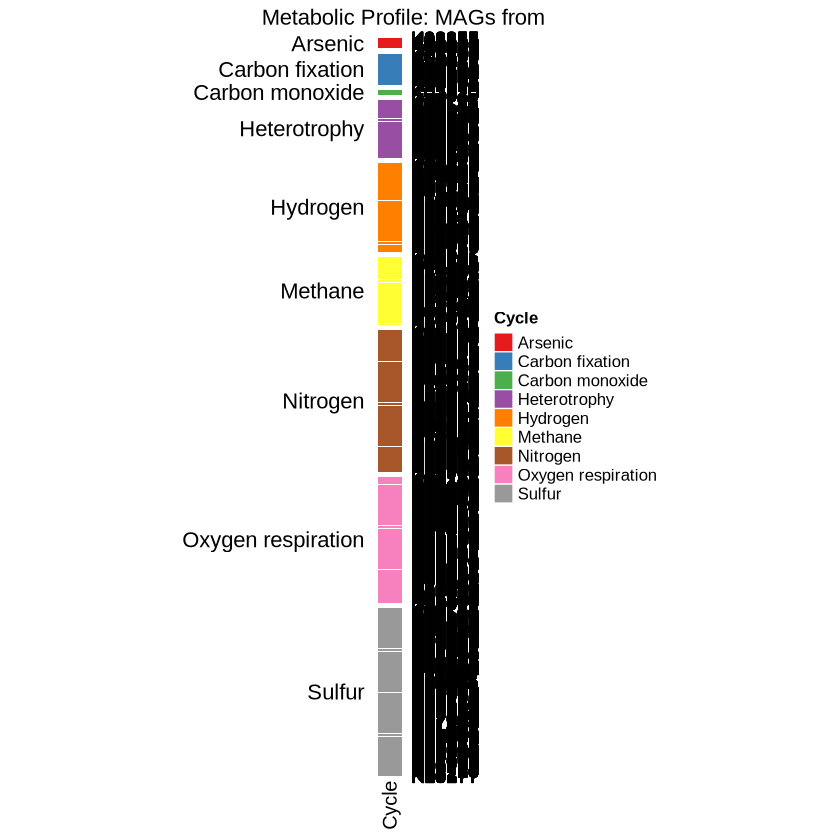

In [ ]:


# 1. Create the Row Annotation (The color bar on the left)
row_ha = rowAnnotation(
    Cycle = plot_data$cycle, 
    col = list(Cycle = cat_colors),
    show_legend = TRUE
)

# 2. Build the Heatmap
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), # Base colors
        
        # This logic colors the '1's based on the row's Category
        cell_fun = function(j, i, x, y, width, height, fill) {
            if(mat[i, j] == 1) {
                grid.rect(x, y, width, height, 
                          gp = gpar(fill = cat_colors[plot_data$cycle[i]], col = NA))
            }
        },
        
        left_annotation = row_ha, # Adds the color bar
        row_split = plot_data$cycle,
        cluster_rows = FALSE, 
        show_column_names = FALSE,
        row_title_rot = 0,
        column_title = paste0("Metabolic Profile: MAGs from "),        
        border = TRUE)

draw(hb, heatmap_legend_side = "right", annotation_legend_side = "right")

In [ ]:
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), 
        
        # 1. ADD GRID LINES for the background (the "0" cells)
        rect_gp = gpar(col = "gray90", lwd = 0.5), 
        
        cell_fun = function(j, i, x, y, width, height, fill) {
            # Draw the background for empty cells so the grid is consistent
            grid.rect(x, y, width, height, gp = gpar(fill = "white", col = "gray90", lwd = 0.5))
            
            if(mat[i, j] == 1) {
                # 2. DRAW COLORED CELLS with a border (col = "white" or "gray90")
                grid.rect(x, y, width, height, 
                          gp = gpar(fill = cat_colors[plot_data$cycle[i]], 
                                    col = "white", # This creates a small gap between colored cells
                                    lwd = 0.5))
            }
        },
        
        left_annotation = row_ha,
        row_split = plot_data$cycle,
        cluster_rows = FALSE, 
        
        # 3. SHOW COLUMN NAMES (essential for identifying individual MAGs)
        show_column_names = TRUE,
        column_names_gp = gpar(fontsize = 8),
        column_names_rot = 90,
        
        row_title_rot = 0,
        column_title = "MAGs (Sample CR18)",
        border = TRUE)

draw(hb, heatmap_legend_side = "right", annotation_legend_side = "right")

Warning message:
“You defined `cell_fun` for a heatmap with more than 100 rows or
columns, which might be very slow to draw. Consider to use the
vectorized version `layer_fun`.”


ERROR: Error: number of observations in left annotation should be same as nrow of the
matrix.


### SINGLE SAMPLE ###


In [ ]:


# Funzione per caricare le tabelle HMM (Functional)
load_hmm <- function(f) {
  s_name <- basename(dirname(f))
  read_delim(f, delim = "\t", show_col_types = FALSE) %>%
    pivot_longer(cols = -HMM_model, names_to = "local_mag", values_to = "val") %>%
    mutate(Global_MAG_ID = paste0(s_name, "_", local_mag),
           presence = ifelse(val == "0", 0, 1)) %>%
    select(HMM_model, Global_MAG_ID, presence)
}

# Funzione per caricare la GTDBTK (Taxonomy)
load_tax <- function(f) {
  s_name <- str_split(basename(f), "\\.")[[1]][1]
  read_delim(f, delim = "\t", show_col_types = FALSE) %>%
    mutate(Global_MAG_ID = paste0(s_name, "_", MAGs)) %>%
    select(Global_MAG_ID, phylum, family)
}

In [ ]:
# Geomosaic organizes these in {wdir}/{sample}/{mags_hmmsearch_output_folder}
files_hmms <- list.files(path = "../tables/gm_gathering/mags_hmmsearch", pattern = "mags.tsv", recursive = TRUE, full.names = TRUE)

file_gtdbtk <- list.files(path = "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples", pattern = ".tsv", recursive = TRUE, full.names = TRUE)

In [ ]:
sampleA_func <- files_hmms[1]
sampleA_func
sampleA_tax <- file_gtdbtk[1]
sampleA_tax 

[1] "../tables/gm_gathering/mags_hmmsearch/CR18_ER180415_F/mags.tsv"

[1] "../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/CR18_ER180415_F.tsv"

In [ ]:
all_hmm <- map_df(sampleA_func, load_hmm)
all_tax <- map_df(sampleA_tax, load_tax)

In [ ]:
all_tax


Global_MAG_ID,phylum,family
<chr>,<chr>,<chr>
CR18_ER180415_F_mag_1,Pseudomonadota,Thiotrichaceae
CR18_ER180415_F_mag_10,Pseudomonadota,Thiomicrospiraceae
CR18_ER180415_F_mag_11,Bacteroidota,Ignavibacteriaceae
CR18_ER180415_F_mag_2,Pseudomonadota,Rhodocyclaceae
CR18_ER180415_F_mag_3,Bacteroidota,F082
CR18_ER180415_F_mag_4,Pseudomonadota,Thiotrichaceae
CR18_ER180415_F_mag_5,Pseudomonadota,Burkholderiaceae
CR18_ER180415_F_mag_6,Cyanobacteriota,CACIAM-69d
CR18_ER180415_F_mag_7,Pseudomonadota,Rhodobacteraceae


In [ ]:
ko_metadata <- read_delim("../tables/geomosaic_biogeochemical_kos_plot.tsv", delim = "\t")
ko_metadata_clean <- ko_metadata %>% 
  distinct(KO, .keep_all = TRUE)

In [ ]:
# 3. Join Finale (Long Format)
plot_data_full <- all_hmm %>%
  left_join(all_tax, by = "Global_MAG_ID") %>%
  left_join(ko_metadata_clean, by = c("HMM_model" = "KO")) %>%
  filter(!is.na(cycle)) %>%  # Teniamo solo i KO presenti nel tuo template
  arrange(cycle)

In [ ]:
# 1. Crea la matrice 'Wide'
mat_df <- plot_data_full %>%
  select(HMM_model, Global_MAG_ID, presence) %>%
  distinct() %>% # Sicurezza contro duplicati
  pivot_wider(names_from = Global_MAG_ID, values_from = presence, values_fill = 0)

# 2. Trasforma in matrice numerica
mat <- as.matrix(mat_df[,-1])
rownames(mat) <- mat_df$HMM_model

# 3. CREA IL METADATO SINCRONIZZATO (Il pezzo mancante!)
# Estraiamo i cicli nell'ordine esatto in cui appaiono nella matrice
meta_rows <- plot_data_full %>%
  select(HMM_model, cycle) %>%
  distinct() %>%
  filter(HMM_model %in% rownames(mat)) %>%
  # Questo 'match' assicura che l'ordine sia lo STESSO di rownames(mat)
  slice(match(rownames(mat), HMM_model))

# 4. Verifica di sicurezza (opzionale ma consigliata)
if(nrow(meta_rows) != nrow(mat)) {
  stop("Errore: Il numero di categorie non corrisponde al numero di KO nella matrice!")
}

In [178]:
# Check IDs from functional table
print("Functional IDs look like:")
print(head(colnames(mat), 3))

# Check IDs from tax table
print("Taxonomy IDs look like:")
print(head(all_tax$Global_MAG_ID, 3))

# Check how many actually match
match_count <- sum(colnames(mat) %in% all_tax$Global_MAG_ID)
print(paste("Successful matches:", match_count, "out of", ncol(mat)))

[1] "Functional IDs look like:"
[1] "CR18_ER180415_F_mag_9" "CR18_ER180415_F_mag_8" "CR18_ER180415_F_mag_1"
[1] "Taxonomy IDs look like:"
[1] "CR18_ER180415_F_mag_1"  "CR18_ER180415_F_mag_10" "CR18_ER180415_F_mag_11"
[1] "Successful matches: 11 out of 11"


In [192]:
tax_aligned <- all_tax[match(colnames(mat), all_tax$Global_MAG_ID), ]
concatenated_labels <- paste0(
  tax_aligned$Global_MAG_ID,      # Already contains Sample_Name + mag_number (e.g., CR18_..._mag_1)
  tax_aligned$phylum,             # e.g., Pseudomonadota
  coalesce(tax_aligned$family, "") # e.g., Thiotrichaceae
)
concatenated_labels <- gsub("[p|f]__", "", concatenated_labels)


In [200]:
# 1. Clean the taxonomy strings (removing prefixes)
phylum_clean <- gsub("p__", "", tax_aligned$phylum)
family_clean <- gsub("f__", "", coalesce(tax_aligned$family, "UnknownFamily"))

# 2. Extract ONLY the MAG number (the last part after the final underscore)
# This turns "CR18_ER180415_F_mag_9" into "mag_9"
mag_numbers <- str_extract(tax_aligned$Global_MAG_ID, "mag_\\d+$")

# 3. Combine them: Phylum_Family_mag_N
concatenated_labels <- paste(phylum_clean, family_clean, mag_numbers, sep = "_")

# Result: 'Pseudomonadota_Chromatiaceae_mag_9'

In [201]:
concatenated_labels[1]

[1] "Pseudomonadota_Chromatiaceae_mag_9"

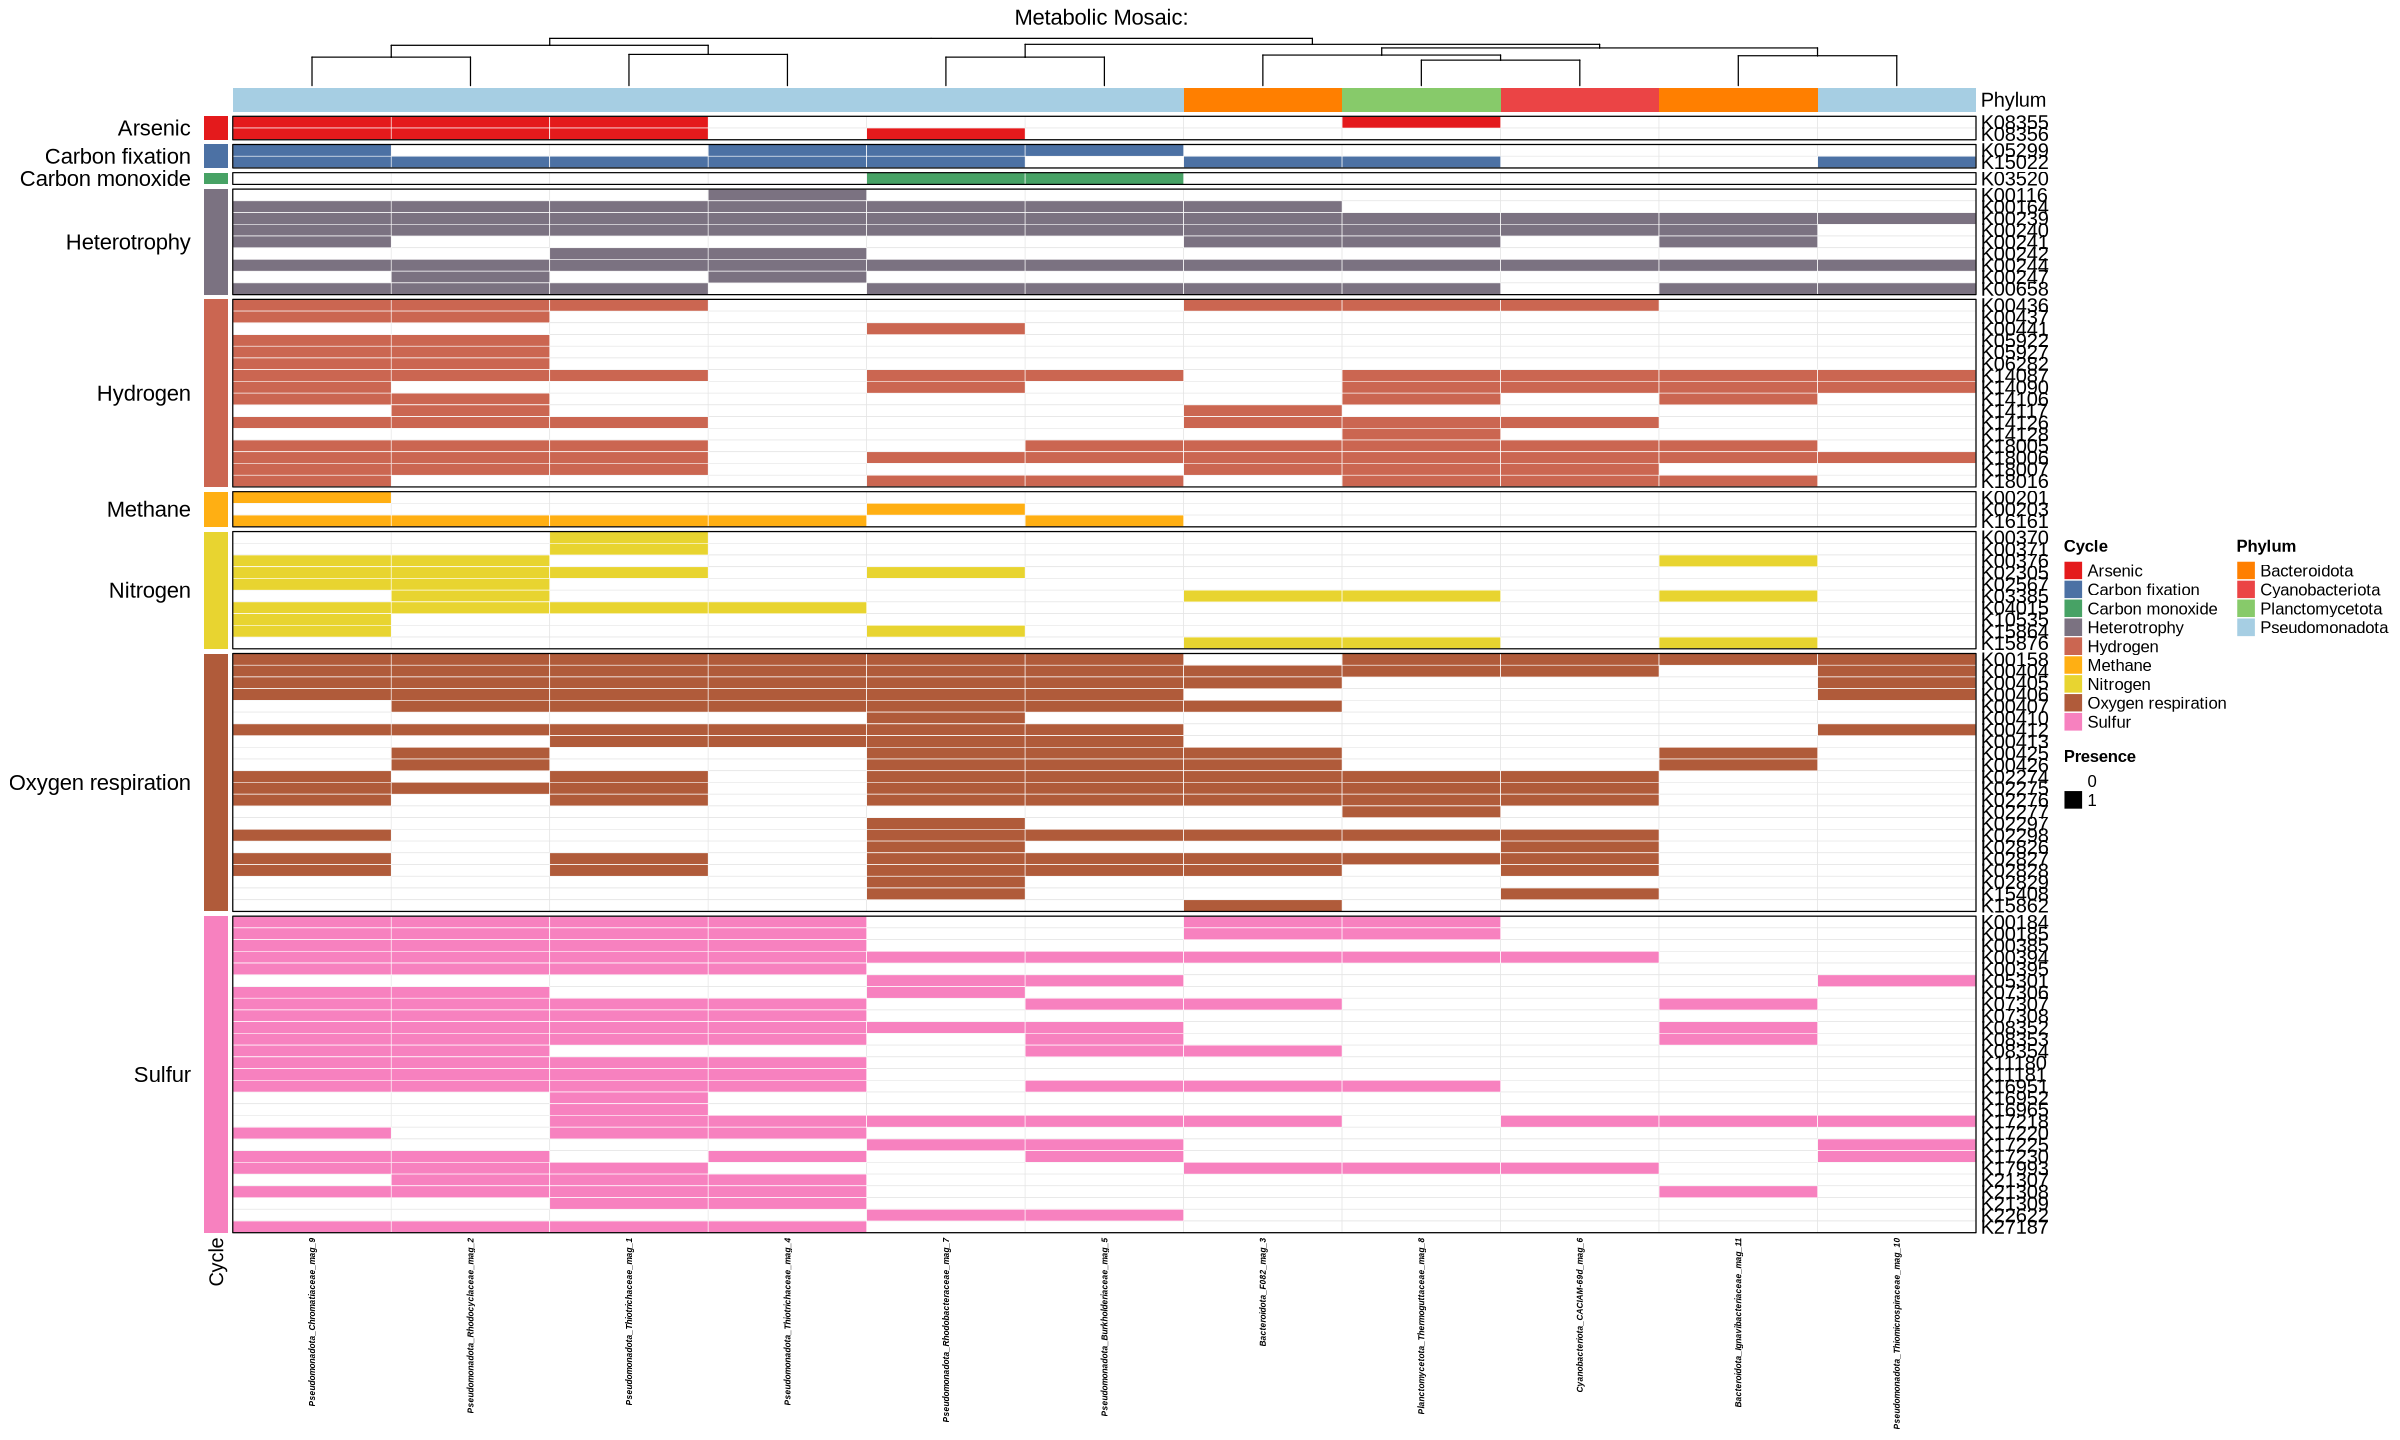

In [202]:
#ALTERNAITVE
# 1. Prepare Taxonomy Colors (Top Annotation)
# We need this so the color bar at the top knows which phylum is which
unique_phyla <- unique(tax_aligned$phylum)
phylum_colors <- setNames(
    colorRampPalette(brewer.pal(8, "Paired"))(length(unique_phyla)), 
    unique_phyla
)

# 2. Prepare Cycle Colors (Cell Coloring)
# This is what your layer_fun uses
unique_cycles <- unique(meta_rows$cycle)
cat_colors <- setNames(
    colorRampPalette(brewer.pal(8, "Set1"))(length(unique_cycles)), 
    unique_cycles
)

# 3. Create the Row Annotation (Left side)
row_ha = rowAnnotation(
    Cycle = meta_rows$cycle, 
    col = list(Cycle = cat_colors),
    show_legend = TRUE
)

# 4. The Heatmap
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), # Base grid
        rect_gp = gpar(col = "gray90", lwd = 0.5), # Visible grid lines
        
        # VECTORIZED COLORING BY CYCLE
        layer_fun = function(j, i, x, y, width, height, fill) {
            v = pindex(mat, i, j)
            l = v == 1
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[meta_rows$cycle[i[l]]], 
                                col = "white", lwd = 0.5))
        },
        
        # COLUMN SETTINGS (Taxonomy labels)
        show_column_names = TRUE,
        column_labels = concatenated_labels, 
        column_names_gp = gpar(fontsize = 5, fontface = "bold.italic"),
        column_names_rot = 90,
        
        # TOP ANNOTATION (Phylum bar)
        top_annotation = HeatmapAnnotation(
            Phylum = tax_aligned$phylum,
            col = list(Phylum = phylum_colors),
            show_legend = TRUE
        ),
        
        # ROW SETTINGS
        left_annotation = row_ha,
        row_split = meta_rows$cycle,
        cluster_rows = FALSE,
        row_title_rot = 0,
        
        column_title = paste0("Metabolic Mosaic: "),
        border = TRUE)


options(repr.plot.width = 20, repr.plot.height = 12)

# Draw with legends on the right
draw(hb, heatmap_legend_side = "right", annotation_legend_side = "right")

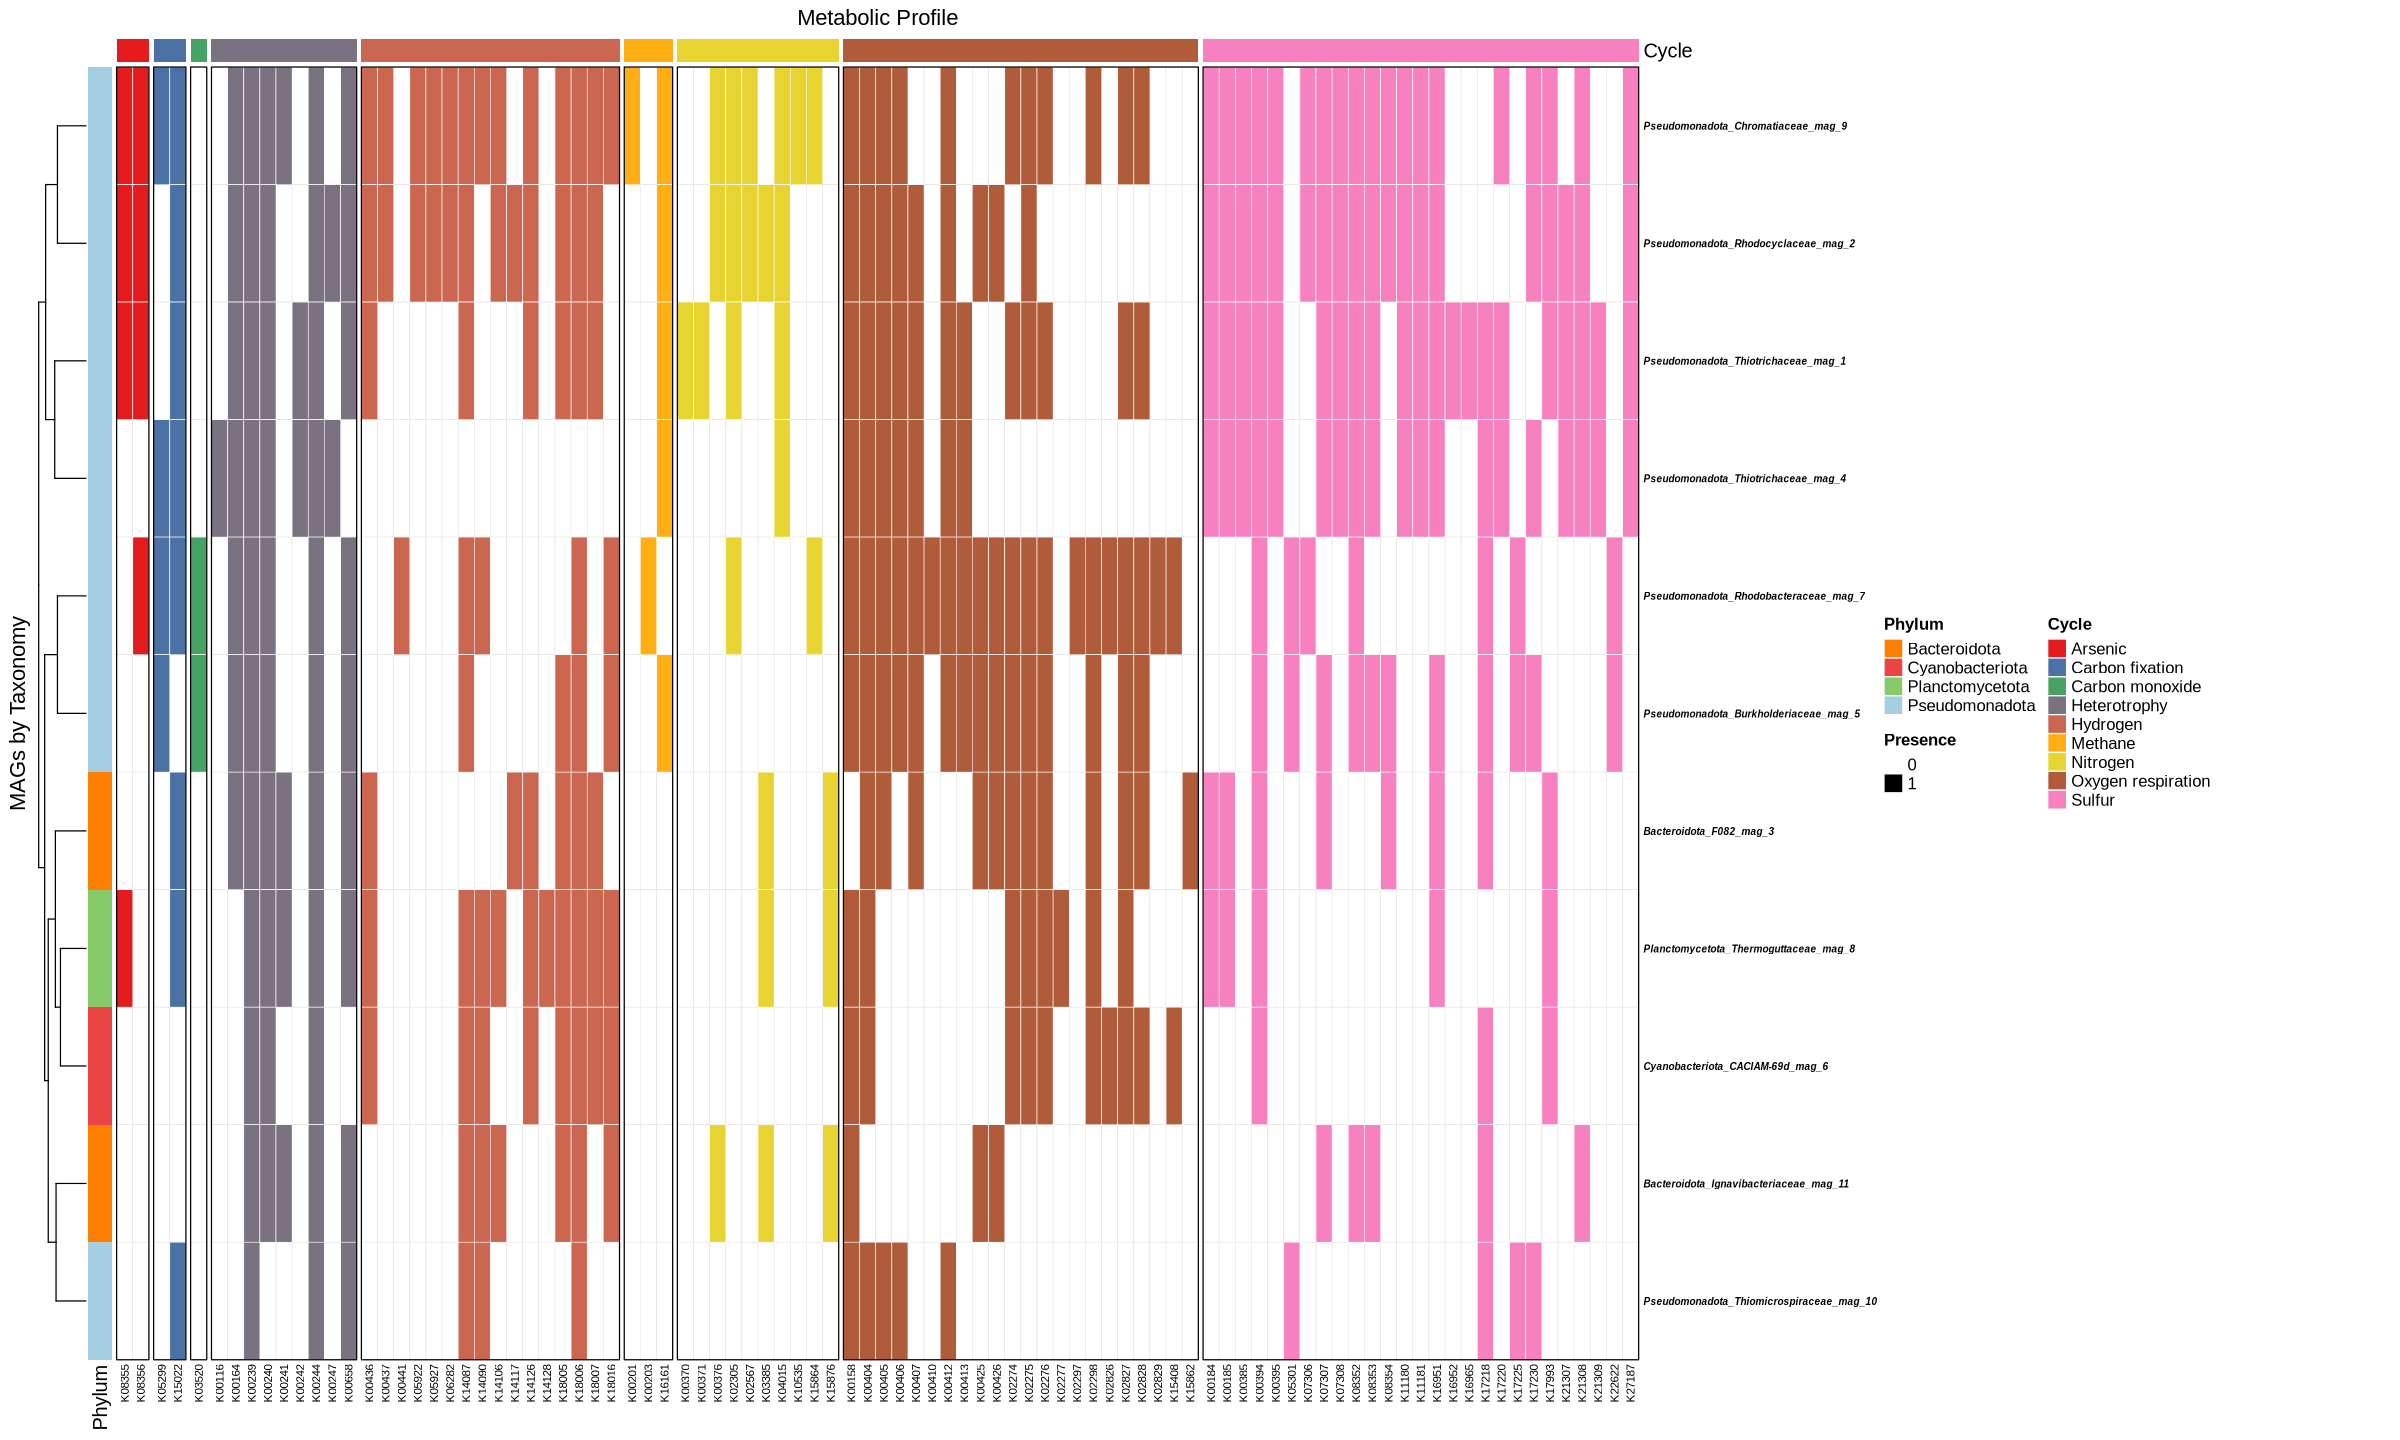

In [203]:
#FLIPPED HEATMAP
# Transpose: Rows become MAGs, Columns become KOs
mat_t <- t(mat)
# 1. Prepare Annotations for the new orientation
# Now MAGs/Taxa are the LEFT annotation
row_ha_tax = rowAnnotation(
    Phylum = tax_aligned$phylum,
    col = list(Phylum = phylum_colors)
)

# Now Cycles are the TOP annotation
col_ha_cycle = HeatmapAnnotation(
    Cycle = meta_rows$cycle,
    col = list(Cycle = cat_colors)
)

# 2. Build the Flipped Heatmap
hb_t <- Heatmap(mat_t, 
        name = "Presence",
        
        col = c("0" = "white", "1" = "black"),
        rect_gp = gpar(col = "gray90", lwd = 0.5),
        
        # VECTORIZED COLORING (Adjusted for transposed indices)
        layer_fun = function(j, i, x, y, width, height, fill) {
            v = pindex(mat_t, i, j)
            l = v == 1
            # Note: We now use cycle info from the columns (j)
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[meta_rows$cycle[j[l]]], 
                                col = "white", lwd = 0.5))
        },
        
        # MAGS / TAXONOMY on Y-AXIS (Rows)
        show_row_names = TRUE,
        row_labels = concatenated_labels,
        row_names_gp = gpar(fontsize = 6, fontface = "bold.italic"),
        left_annotation = row_ha_tax,
        
        # KOs / CYCLES on X-AXIS (Columns)
        show_column_names = TRUE,
        column_names_gp = gpar(fontsize = 7),
        top_annotation = col_ha_cycle,
        column_split = meta_rows$cycle, # Splits columns by metabolism
        
        cluster_rows = TRUE,    # You can now cluster MAGs by similarity!
        cluster_columns = FALSE, 
        column_title = "Metabolic Profile",
        row_title = "MAGs by Taxonomy",
        border = TRUE)

options(repr.plot.width = 20, repr.plot.height = 12)

draw(hb_t,
    heatmap_legend_side = "right", 
    padding = unit(c(2, 2, 2, 40), "mm"))

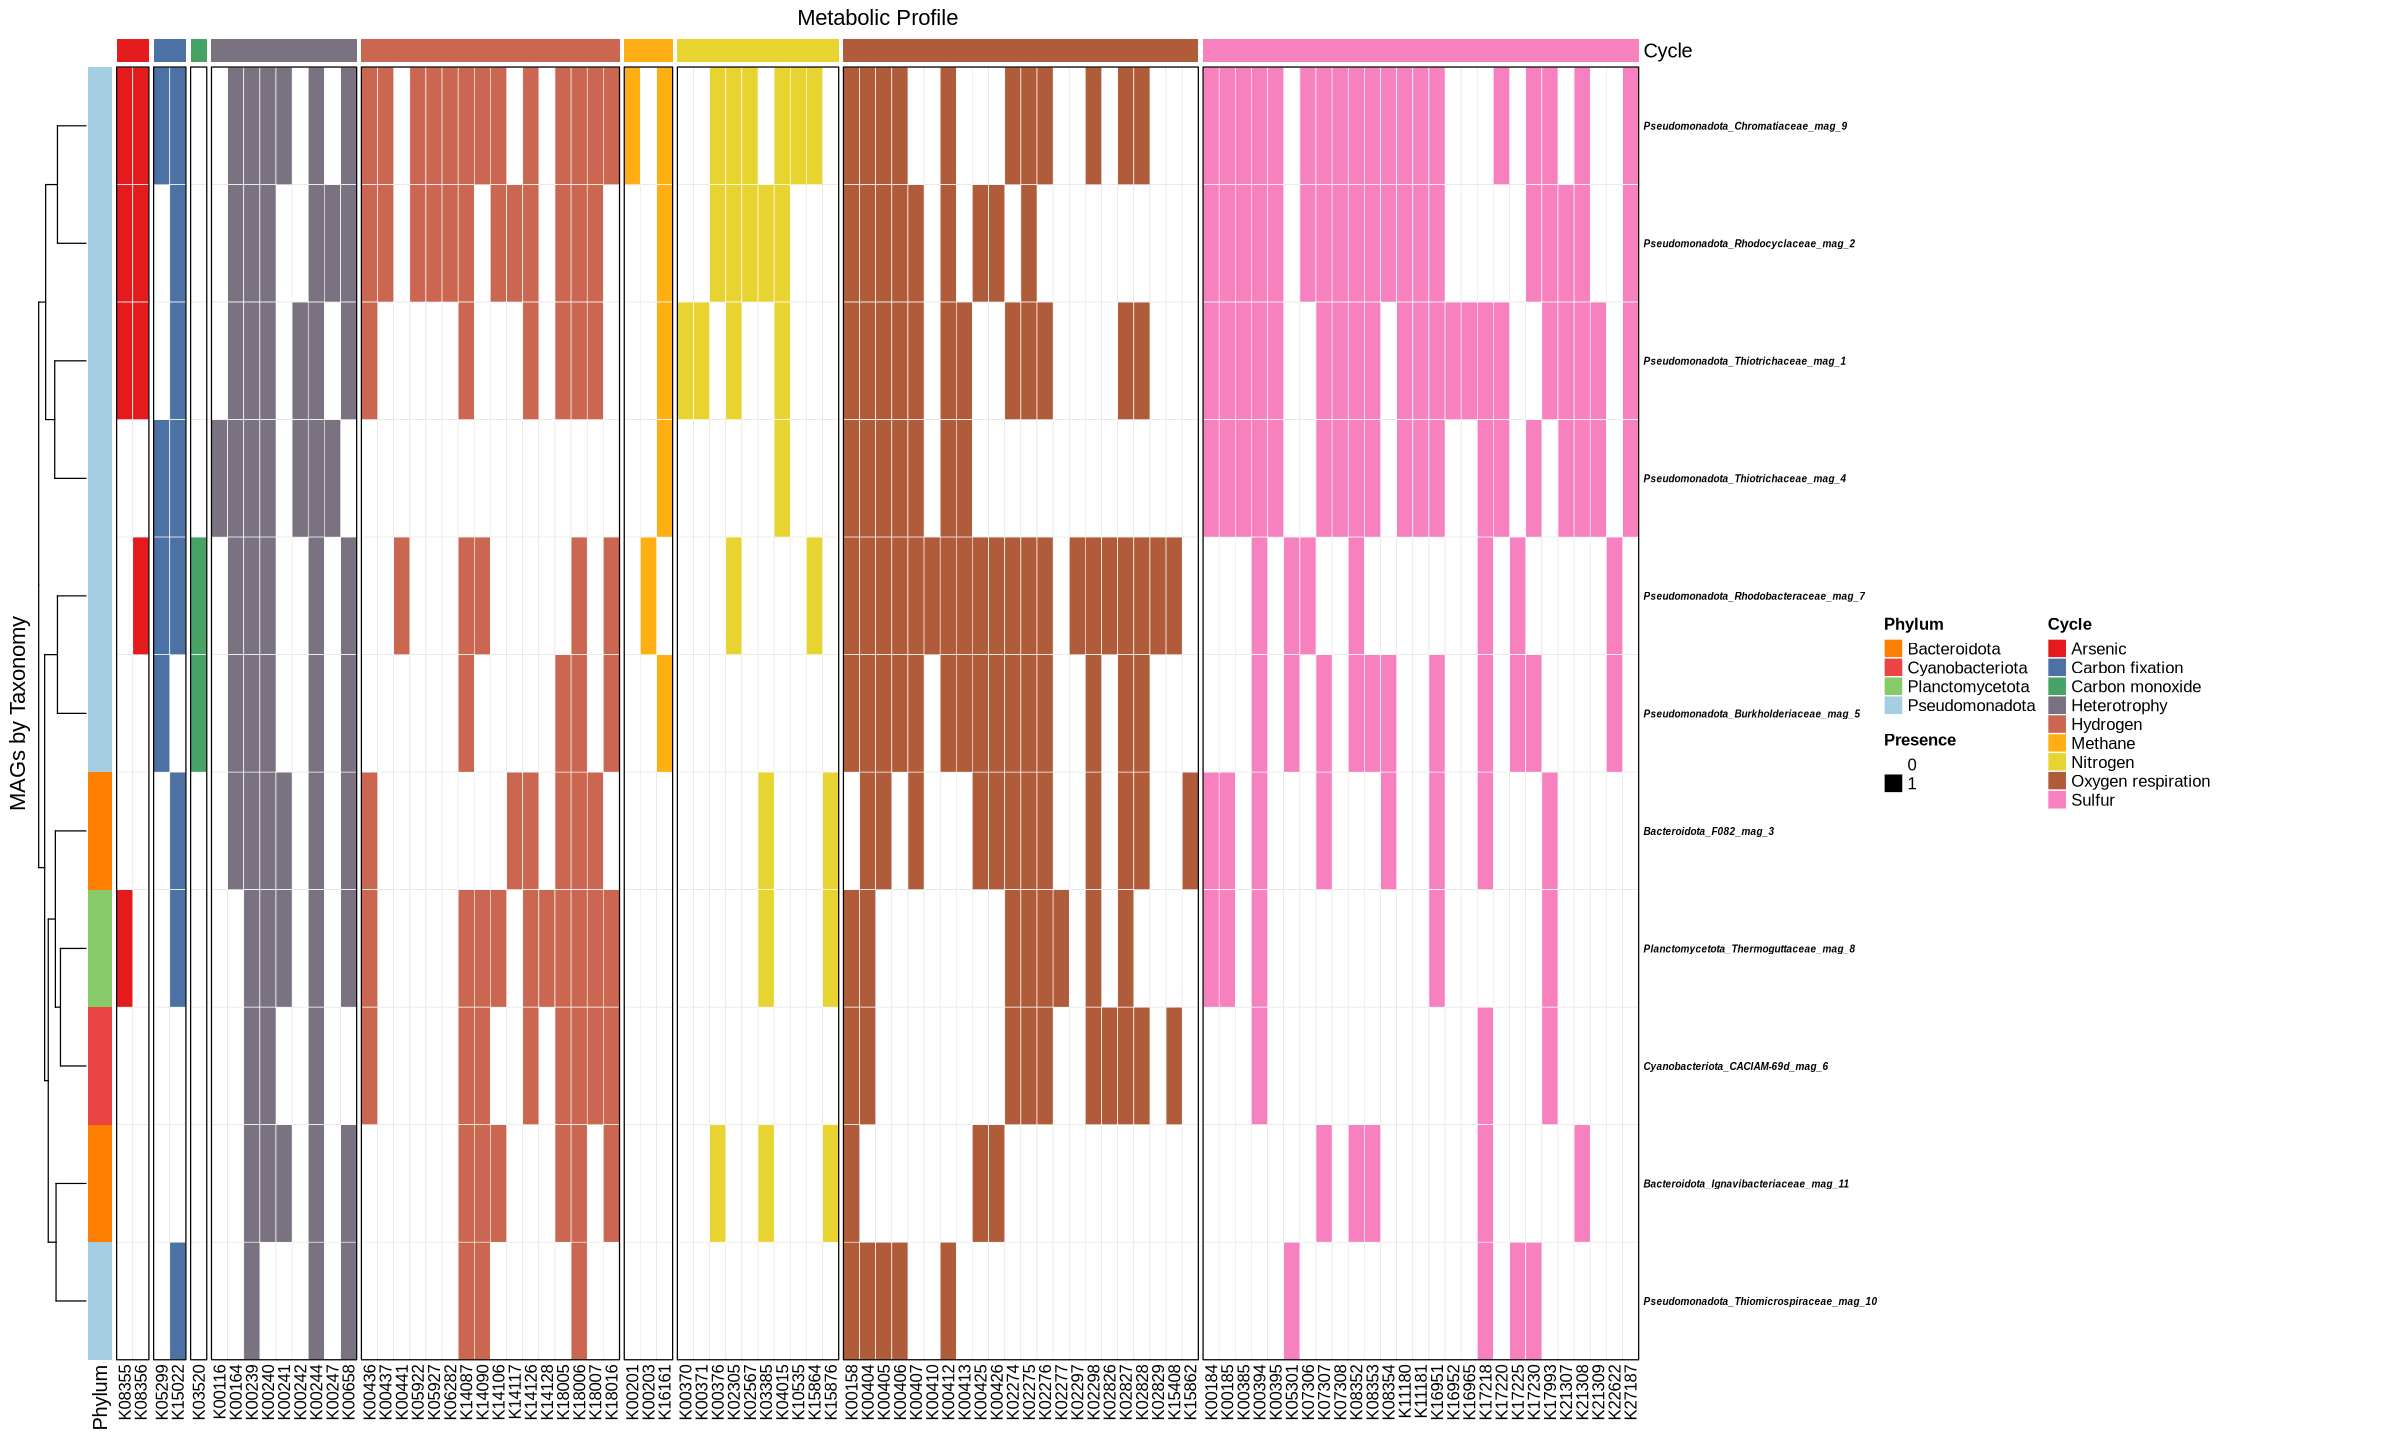

In [204]:
#FLIPPED HEATMAP
# Transpose: Rows become MAGs, Columns become KOs
mat_t <- t(mat)
# 1. Prepare Annotations for the new orientation
# Now MAGs/Taxa are the LEFT annotation
row_ha_tax = rowAnnotation(
    Phylum = tax_aligned$phylum,
    col = list(Phylum = phylum_colors)
)

# Now Cycles are the TOP annotation
col_ha_cycle = HeatmapAnnotation(
    Cycle = meta_rows$cycle,
    col = list(Cycle = cat_colors)
)

# 2. Build the Flipped Heatmap
hb_t <- Heatmap(mat_t, 
        name = "Presence",
        
        col = c("0" = "white", "1" = "black"),
        rect_gp = gpar(col = "gray90", lwd = 0.5),
        
        # VECTORIZED COLORING (Adjusted for transposed indices)
        layer_fun = function(j, i, x, y, width, height, fill) {
            v = pindex(mat_t, i, j)
            l = v == 1
            # Note: We now use cycle info from the columns (j)
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[meta_rows$cycle[j[l]]], 
                                col = "white", lwd = 0.5))
        },
        
        # MAGS / TAXONOMY on Y-AXIS (Rows)
        show_row_names = TRUE,
        row_labels = concatenated_labels,
        row_names_gp = gpar(fontsize = 6, fontface = "bold.italic"),
        left_annotation = row_ha_tax,
        
        # KOs / CYCLES on X-AXIS (Columns)
        show_column_names = TRUE,
        column_names_gp = gpar(fontsize = 10),
        top_annotation = col_ha_cycle,
        column_split = meta_rows$cycle, # Splits columns by metabolism
        
        cluster_rows = TRUE,    # You can now cluster MAGs by similarity!
        cluster_columns = FALSE, 
        column_title = "Metabolic Profile",
        row_title = "MAGs by Taxonomy",
        border = TRUE)

options(repr.plot.width = 20, repr.plot.height = 12)

draw(hb_t,
    heatmap_legend_side = "right", 
    padding = unit(c(2, 2, 2, 40), "mm"))

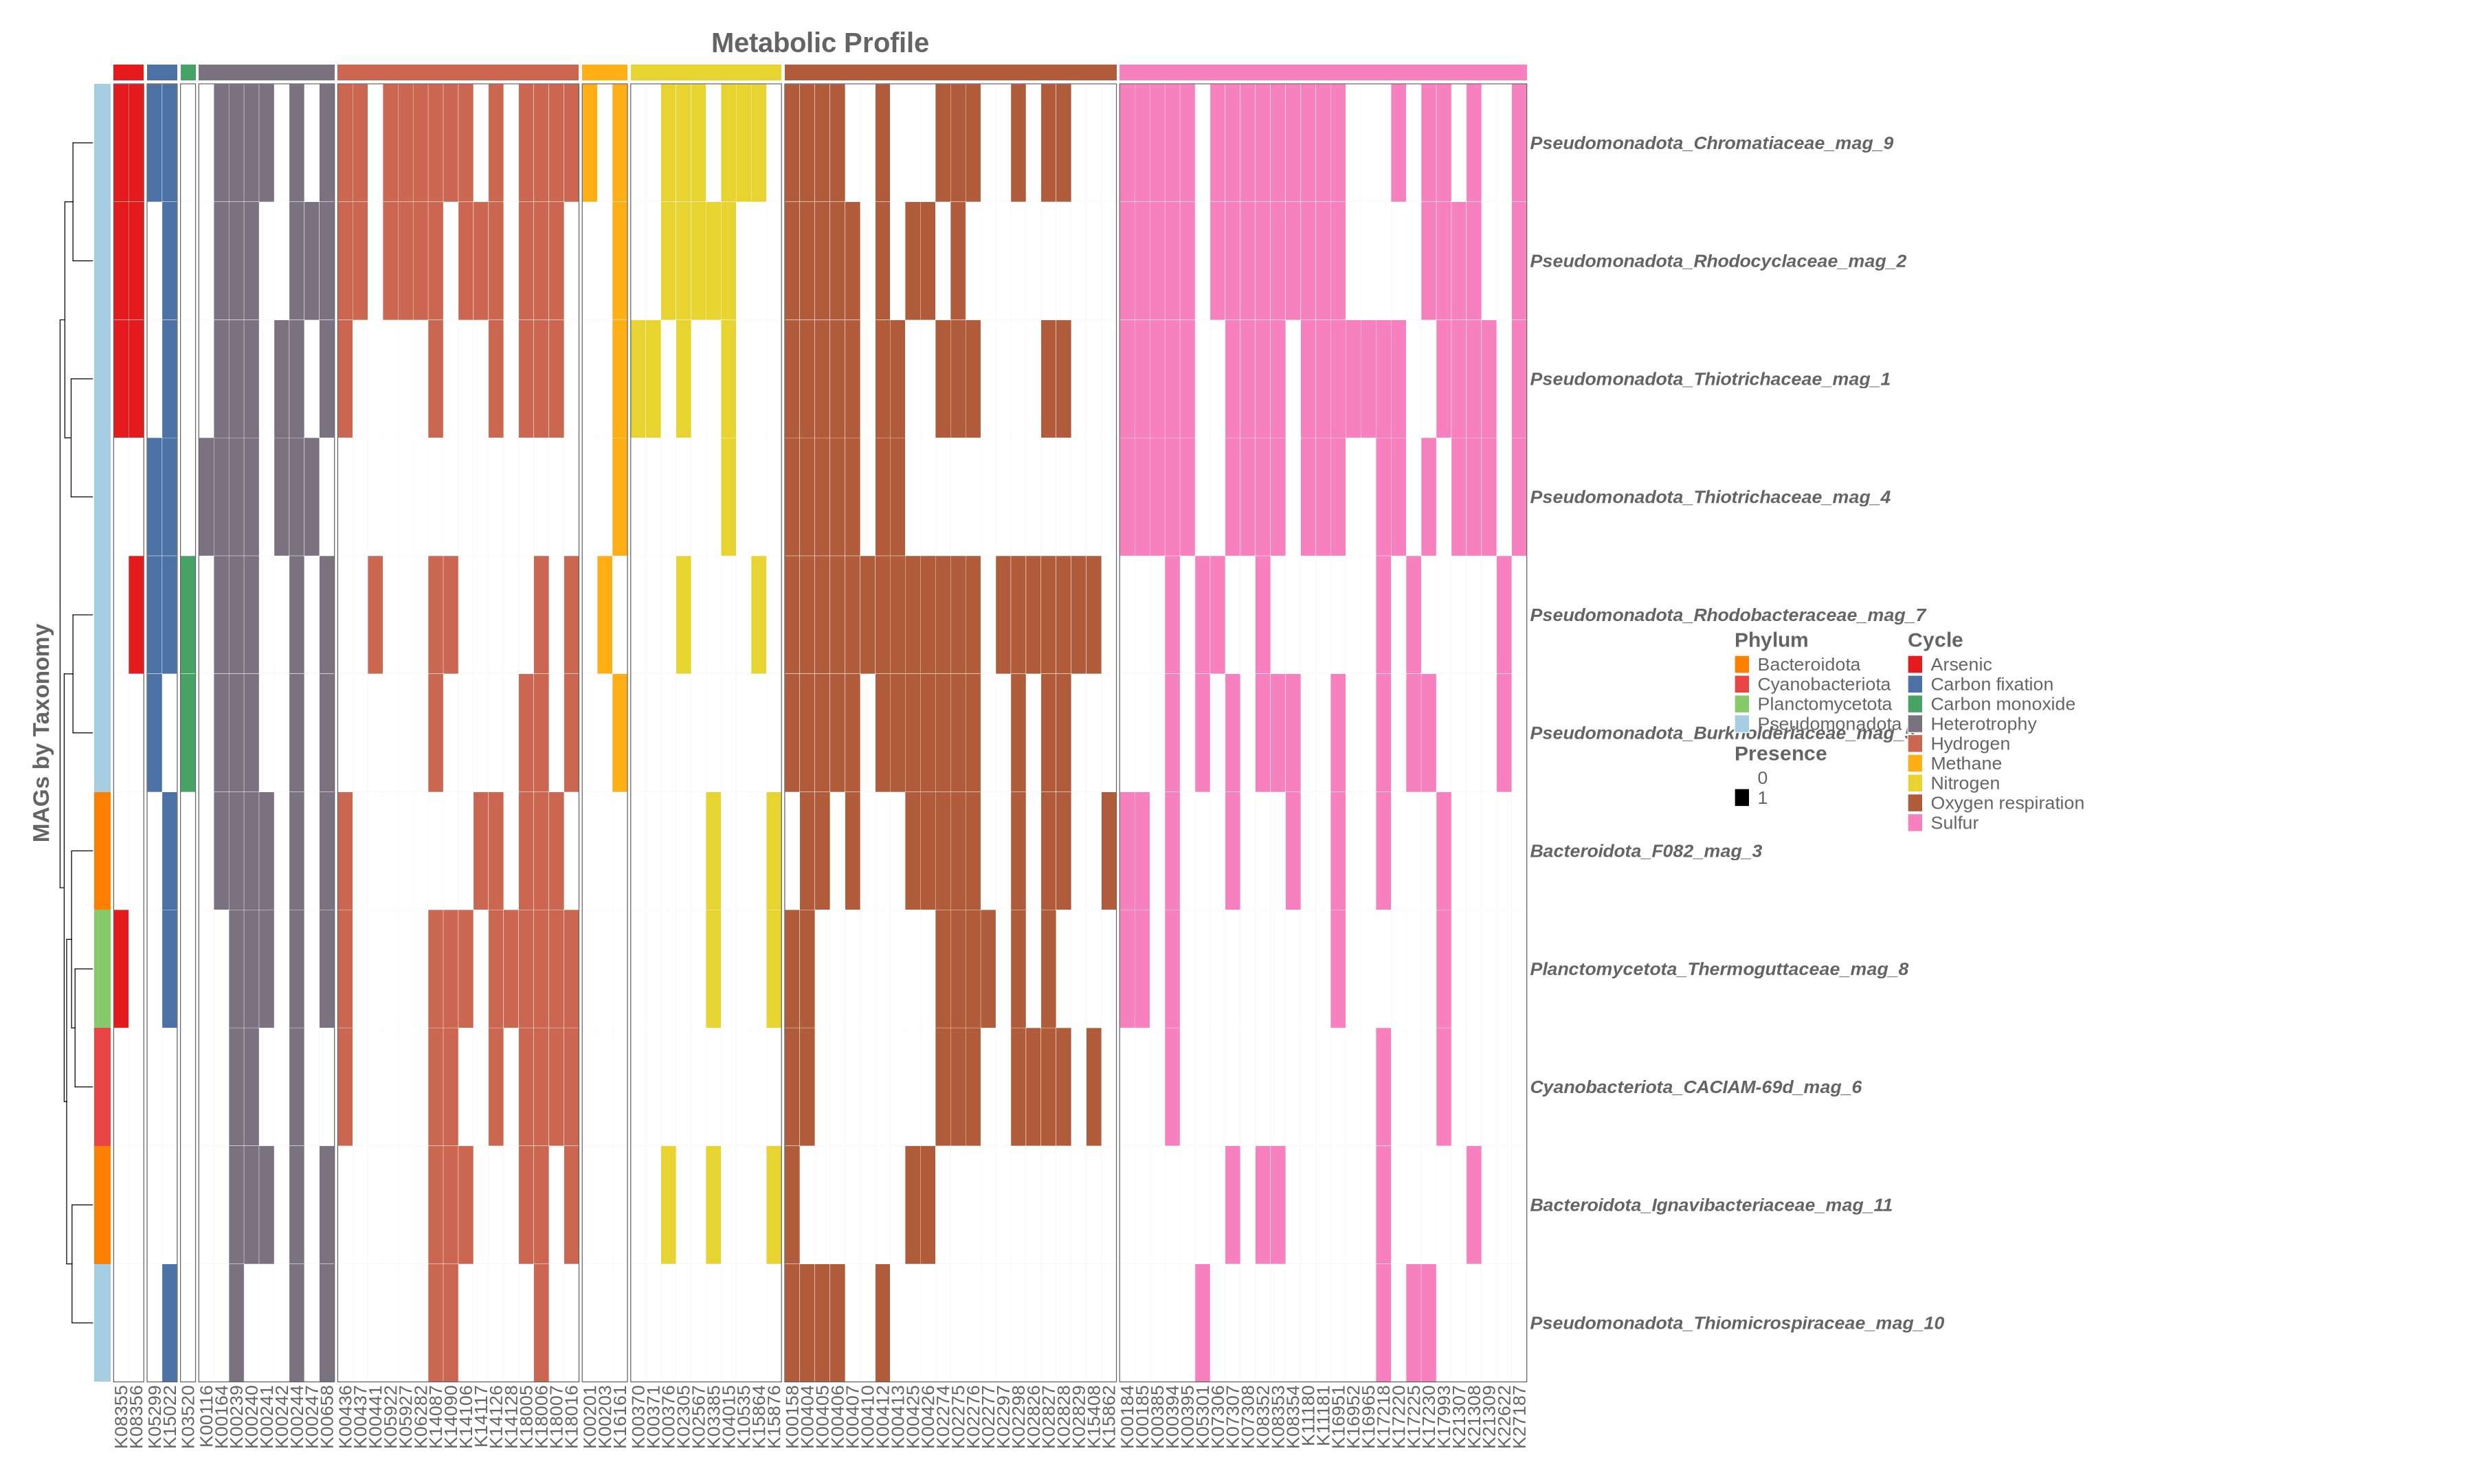

In [205]:
# --- 1. THEME TRANSLATION SETUP (INCREASED SIZES) ---
base_s <- 20                        # Increased from 11 to 20
lab_gray <- rgb(100, 100, 100, maxColorValue = 255)
text_s <- base_s * 0.8              # Increased relative scale from 0.65 to 0.8

# --- 2. TRANSPOSE DATA ---
mat_t <- t(mat)

# --- 3. PREPARE ANNOTATIONS WITH BIG FONT ---
leg_param <- list(
    title_gp = gpar(col = lab_gray, fontsize = text_s + 2, fontface = "bold"),
    labels_gp = gpar(col = lab_gray, fontsize = text_s),
    grid_height = unit(1.2, "lines"), # Bigger color boxes in legend
    grid_width = unit(1.2, "lines")
)

row_ha_tax = rowAnnotation(
    Phylum = tax_aligned$phylum,
    col = list(Phylum = phylum_colors),
    annotation_legend_param = list(Phylum = leg_param),
    show_annotation_name = FALSE,
    width = unit(10, "mm") # Wider color bar for phylum
)

col_ha_cycle = HeatmapAnnotation(
    Cycle = meta_rows$cycle,
    col = list(Cycle = cat_colors),
    annotation_legend_param = list(Cycle = leg_param),
    show_annotation_name = FALSE,
    height = unit(10, "mm") # Taller color bar for cycles
)

# --- 4. BUILD THE HEATMAP ---
hb_t <- Heatmap(mat_t, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"),
        
        # Border and Grid
        border = lab_gray,
        rect_gp = gpar(col = "gray95", lwd = 0.3), 
        
        layer_fun = function(j, i, x, y, width, height, fill) {
            v = pindex(mat_t, i, j)
            l = v == 1
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[meta_rows$cycle[j[l]]], 
                                col = "white", lwd = 0.3))
        },
        
        # Y-AXIS (Rows) - BIG FONT
        show_row_names = TRUE,
        row_labels = concatenated_labels,
        row_names_gp = gpar(col = lab_gray, fontsize = text_s, fontface = "bold.italic"),
        left_annotation = row_ha_tax,
        row_names_side = "right",
        
        # X-AXIS (Columns) - BIG FONT
        show_column_names = TRUE,
        column_names_gp = gpar(col = lab_gray, fontsize = text_s),
        top_annotation = col_ha_cycle,
        column_split = meta_rows$cycle,
        
        # TITLES - BIG FONT
        column_title = "Metabolic Profile",
        column_title_gp = gpar(col = lab_gray, fontsize = base_s + 4, fontface = "bold"),
        row_title = "MAGs by Taxonomy",
        row_title_gp = gpar(col = lab_gray, fontsize = base_s, fontface = "bold"),
        
        heatmap_legend_param = leg_param,
        
        cluster_rows = TRUE, 
        cluster_columns = FALSE
)

# --- 5. DRAWING (MASSIVE CANVAS) ---
# We need a much wider/taller canvas for large fonts
options(repr.plot.width = 30, repr.plot.height = 18)

draw(hb_t, 
     heatmap_legend_side = "right", 
     annotation_legend_side = "right",
     # Massive padding to prevent the large text from clipping
     padding = unit(c(10, 10, 10, 120), "mm"))

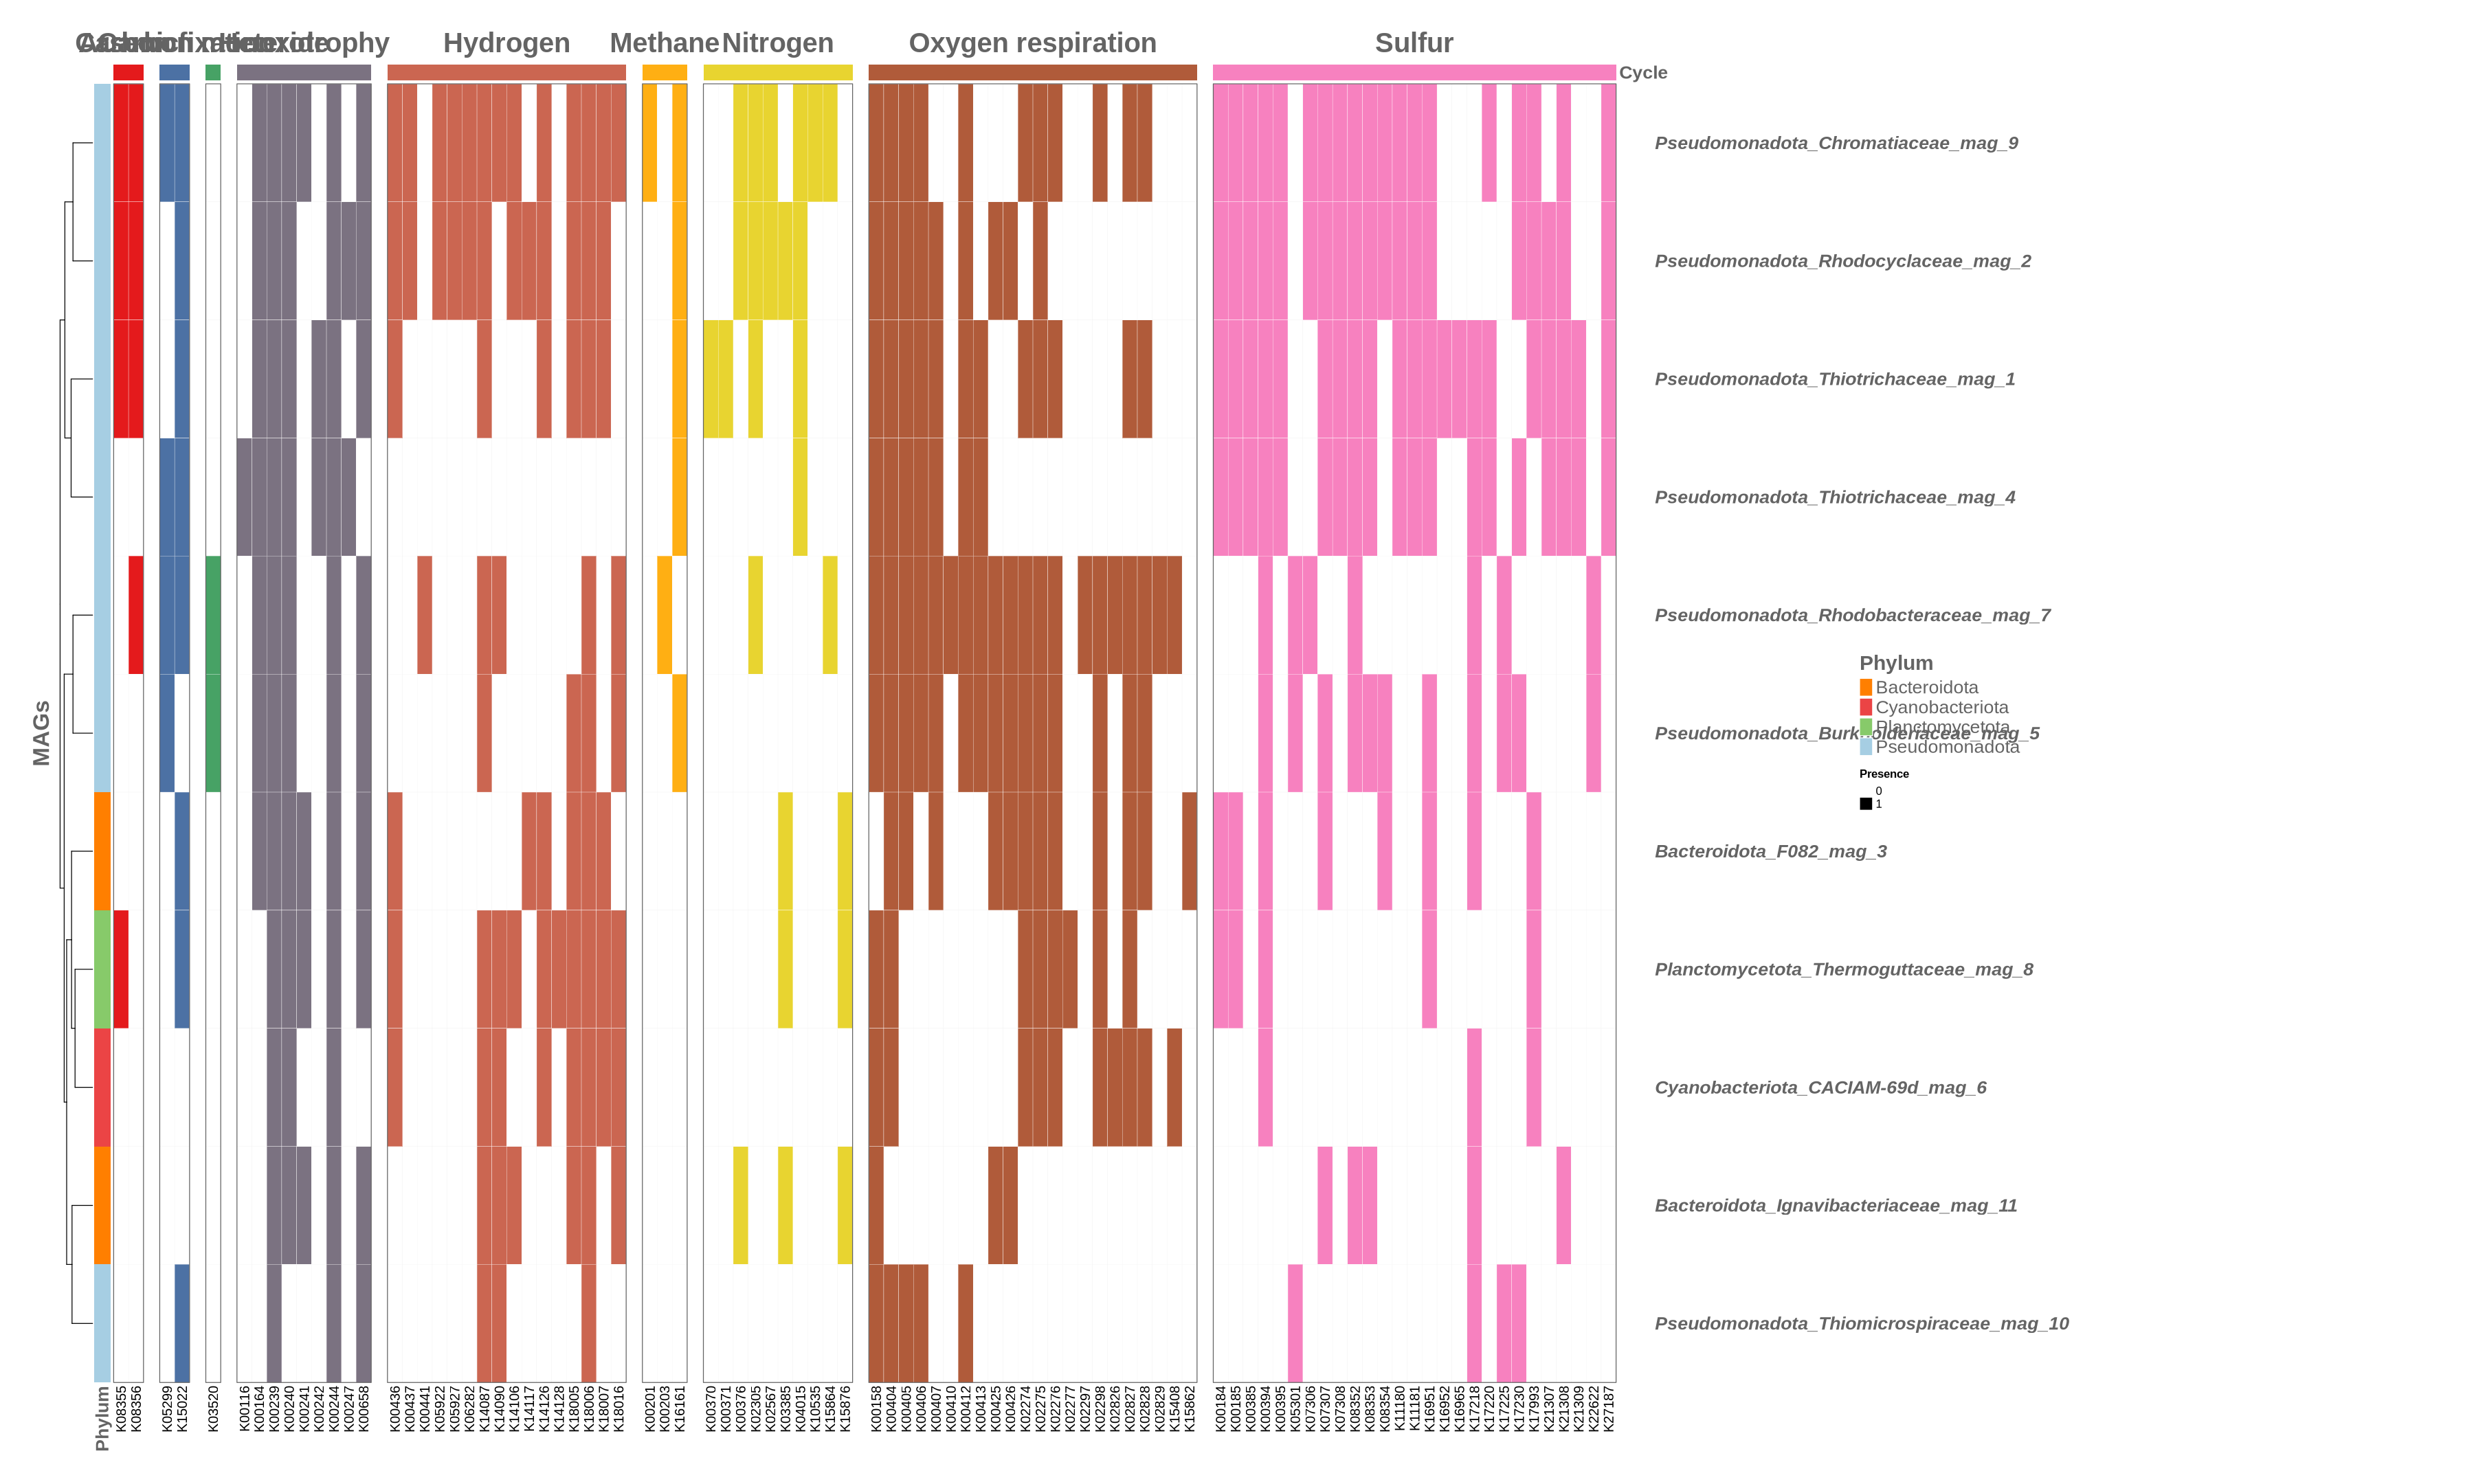

In [216]:
# 1. Calcoliamo i nomi dei cicli unici nell'ordine dello split
# Questo assicura che il titolo corrisponda al blocco di colonne
cycle_titles <- unique(as.character(meta_rows$cycle))

# 2. Ricostruzione Heatmap
hb_t <- Heatmap(mat_t, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"),
        border = lab_gray,
        rect_gp = gpar(col = "gray95", lwd = 0.3), 
        
        layer_fun = function(j, i, x, y, width, height, fill) {
            v = pindex(mat_t, i, j)
            l = v == 1
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[meta_rows$cycle[j[l]]], 
                                col = "white", lwd = 0.3))
        },
        
        # ASSE Y (MAGs)
        show_row_names = TRUE,
        row_labels = concatenated_labels,
        row_names_side = "right",
        row_names_gp = gpar(col = lab_gray, fontsize = text_s, fontface = "bold.italic"),
        right_annotation = right_padding, 
        
        # ASSE Y (Phylum)
        left_annotation = left_ha_tax,
        
        # ASSE X (Cicli)
        top_annotation = top_ha_cycle,
        column_split = meta_rows$cycle,
        
        # --- TITOLI CORRETTI ---
        # Passiamo direttamente il vettore dei nomi
        column_title = cycle_titles, 
        column_title_gp = gpar(col = lab_gray, fontsize = base_s + 4, fontface = "bold"),
        column_gap = unit(5, "mm"),
        
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        row_title = "MAGs",
        row_title_gp = gpar(col = lab_gray, fontsize = base_s, fontface = "bold")
)

# --- DISEGNO ---
options(repr.plot.width = 30, repr.plot.height = 18)
draw(hb_t, padding = unit(c(10, 10, 10, 140), "mm"))

In [220]:
# 1. Split rows by taxa (phylum or whatever taxonomic level)
taxa_titles <- unique(as.character(tax_aligned$phylum))  # adjust to your meta

hb_t <- Heatmap(mat_t, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"),
        border = lab_gray,
        rect_gp = gpar(col = "gray95", lwd = 0.3), 

        layer_fun = function(j, i, x, y, width, height, fill) {
            v = pindex(mat_t, i, j)
            l = v == 1
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[meta_rows$cycle[j[l]]], 
                                col = "white", lwd = 0.3))
        },
        
        # ASSE Y (MAGs)
        show_row_names = TRUE,
        row_labels = concatenated_labels,
        row_names_side = "right",
        row_names_gp = gpar(col = lab_gray, fontsize = text_s, fontface = "bold.italic"),
        right_annotation = right_padding, 
        
        # TAXA INLINE — replaces left_annotation legend
        row_split = tax_aligned$phylum,,         # split rows by taxon
        row_title = taxa_titles,              # one title per block
        row_title_side = "left",              # place on the left (where left_ha_tax was)
        row_title_gp = gpar(
            col = phylum_colors[taxa_titles],    # match your taxa color palette
            fontsize = base_s,
            fontface = "bold"
        ),
        row_gap = unit(2, "mm"),              # gap between taxa blocks
        
        # ASSE X (Cicli)
        top_annotation = top_ha_cycle,
        column_split = meta_rows$cycle,
        column_title = cycle_titles, 
        column_title_gp = gpar(col = lab_gray, fontsize = base_s + 4, fontface = "bold"),
        column_gap = unit(5, "mm"),
        
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        row_title_rot = 0,                    # horizontal text (easier to read)
)
options(repr.plot.width = 30, repr.plot.height = 18)
draw(hb_t, padding = unit(c(10, 10, 10, 140), "mm"))

ERROR: Error: Cannot create zero-length unit vector ("unit" subsetting)


ERROR: Error: Cannot create zero-length unit vector ("unit" subsetting)


In [206]:
View(raw_data[0:4, ])

ERROR: Error: object 'raw_data' not found


In [ ]:
binary_matrix <- as.data.frame(lapply(raw_data, function(x) ifelse(x != "0", 1, 0)))
rownames(binary_matrix) <- rownames(raw_data)
# Sort so mag_2 comes before mag_10
sorted_names <- str_sort(colnames(binary_matrix), numeric = TRUE)
binary_matrix <- binary_matrix[, sorted_names]
View(binary_matrix[0:4, ])


,mag_1,mag_2,mag_3,mag_4,mag_5,mag_6,mag_7,mag_8,mag_9,mag_10,mag_11
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
K00003,1,1,0,1,1,1,1,1,1,1,0
K00004,0,1,0,0,1,1,1,1,1,0,1
K00005,0,0,0,0,1,0,0,1,0,0,0
K00007,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
# selecting carbon related KOs
kos_table <- as.data.frame(read_delim("../tables/ko_carbon_metab.csv",
  delim = ","
))

kos <- kos_table$ko
present_kos <- kos[kos %in% rownames(binary_matrix)]
final_matrix <- binary_matrix[present_kos, ]

In [ ]:
# Carbon related KOs from 
# url_bige = 'https://raw.githubusercontent.com/ArnaudBelcour/bigecyhmm/refs/heads/main/bigecyhmm/hmm_databases/hmm_table_template.tsv'

kos <- c('K01938', 'K18861', 'K15231', 'K14466', 'K00197', 'K14469', 'K15230', 'K00198', 'K01601', 'K14467', 'K14468', 'K00194')
present_kos <- kos[kos %in% rownames(binary_matrix)]
final_matrix <- as.matrix(binary_matrix[present_kos, ])

In [ ]:
class(present_kos)
dim(kos)
dim(final_matrix)

[1] "character"

NULL

[1]  5 11

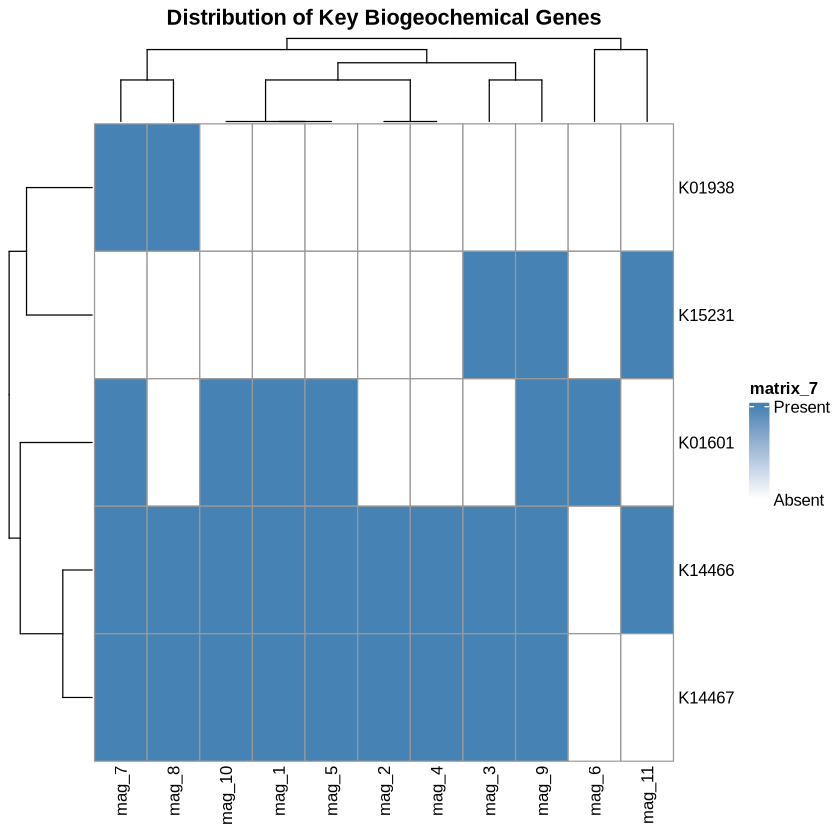

In [ ]:
pheatmap(final_matrix, 
         color = c("white", "steelblue"), 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         legend_breaks = c(0, 1),
         legend_labels = c("Absent", "Present"),
         main = "Distribution of Key Biogeochemical Genes")

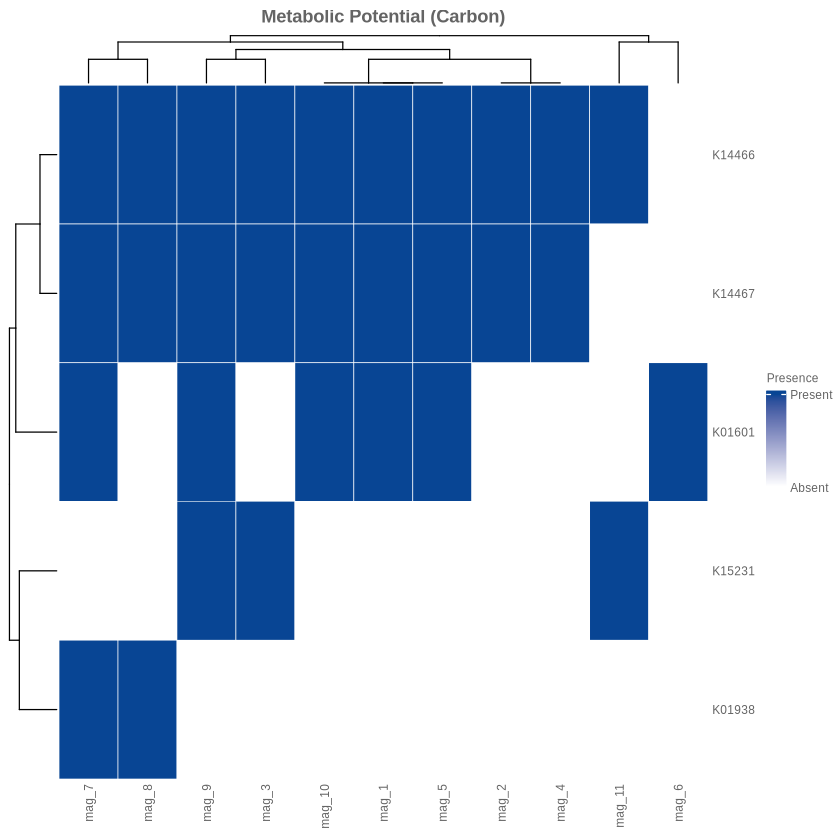

In [ ]:
library(ComplexHeatmap)
library(circlize)
# 1. Define the core color from your theme_glab
glab_gray <- rgb(100, 100, 100, maxColorValue = 255)
# 2. Setup the Heatmap with theme_glab's visual identity
# Using your theme's font sizing (rel(0.65) of 11 is ~7.15)
ht <- Heatmap(final_matrix,
        name = "Presence",
        # Color palette: White to a bold Blue, consistent with your theme's clean BW base
        col = colorRamp2(c(0, 1), c("#FFFFFF", "#084594")),
        # Grid settings matching your panel.border and element_blank() grid
        rect_gp = gpar(col = "white", lwd = 0.5), 
        column_title = "Metabolic Potential (Carbon)",
        column_title_gp = gpar(col = glab_gray, fontsize = 11, fontface = "bold"),
        # Axis/Labels matching your axis.text and axis.title specs
        row_names_gp = gpar(col = glab_gray, fontsize = 7.15),
        column_names_gp = gpar(col = glab_gray, fontsize = 7.15),
        # Clustering options
        cluster_rows = TRUE,
        cluster_columns = TRUE,
        # Legend styling matching your legend.text and legend.title
        heatmap_legend_param = list(
            title_gp = gpar(col = glab_gray, fontsize = 7.15),
            labels_gp = gpar(col = glab_gray, fontsize = 7.15),
            grid_height = unit(0.8, "lines"),
            at = c(0, 1),
            labels = c("Absent", "Present")
        )
)
# 3. Draw with a clean border matching your panel.border
draw(ht, padding = unit(c(2, 2, 2, 2), "mm"))

In [ ]:
ht <- Heatmap(carbon_matrix, 
        name = "Presence", 
        col = col_fun,
        # Clustering & Structure
        cluster_rows = TRUE, 
        cluster_columns = TRUE,
        column_title = "Reconstructed MAGs (Carbon Metabolism)",
        row_title = "HMM Models (KOs)",
        # Visual Styling
        rect_gp = gpar(col = "white", lwd = 1), # White borders between tiles
        show_row_dend = TRUE, 
        show_column_dend = TRUE,
        # Legend Customization
        heatmap_legend_param = list(
            at = c(0, 1), 
            labels = c("Absent", "Present"),
            title = "Status"
        ),
        
        # Font settings for scientific readability
        row_names_gp = gpar(fontsize = 9, fontfamily = "sans"),
        column_names_gp = gpar(fontsize = 10, fontfamily = "sans")
)

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


ERROR: Error: object 'col_fun' not found


A) Phylogenetic tree of the obtained MAGs taxonomically identified using the GTDB-tk module and plotted using iTOL. B) Heatmap of the distribution of key biogeochemical genes obtained using the MAGs-HMM Annotation (MAG-HMMA) module and plotted in R.